# WSE Hawkes Calibration

This notebook fits a **6-dimensional Hawkes process** to WSE order-flow data
using the `HawkesCalibration` class from `research_core.classes`.

## Kernel specifications

| Mode | Kernel | Parameters fitted | Decay search |
|------|--------|-------------------|--------------|
| **Single-exp** | $\phi_{ij}(t) = \alpha_{ij}\beta_{ij}e^{-\beta_{ij}t}$ | $\mu_i,\;\alpha_{ij},\;\beta_{ij}$ | Optuna |
| **Double-exp** | $\phi_{ij}(t) = \sum_{u=1}^{2}\alpha^u_{ij}\beta^u e^{-\beta^u t}$ | $\mu_i,\;\alpha^1_{ij},\;\alpha^2_{ij}$ | **Fixed** $\beta_{\text{fast}},\;\beta_{\text{slow}}$ |

## Event dimensions

`MO_bid`, `MO_ask`, `LO_bid`, `LO_ask`, `CXL_bid`, `CXL_ask`

## Calibration pipeline

1. **Poisson** baseline (raw time + $\tau$-time)
2. **Univariate** self-exciting Hawkes — single-exp (raw + $\tau$)
3. **Multivariate** mutually exciting Hawkes — single-exp (raw + $\tau$)
4. **Univariate** self-exciting Hawkes — double-exp (raw + $\tau$)
5. **Multivariate** mutually exciting Hawkes — double-exp (raw + $\tau$)

In [ ]:
%pip install -e ..

In [4]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from research_core.classes import (
    HawkesCalibration,
    helpers,
    compute_end_times,
    list_day_keys,
    load_events_from_sqlite_bulk,
    estimate_seasonality_profiles,
    project_root,
    data_dir,
    run_full_extraction
)
from research_core.classes.calibrate import (
    get_average_seasonality_shape,
    plot_all_seasonality_patterns,
)

In [5]:
ROOT = project_root()

ASSETS = {"KGHM": 10783, "PKNORLEN": 11319, "PKOBP": 11314, "PZU": 10735, "PEKAO": 11322}

asset = "KGHM"

N_DAYS = 229
DAY_START_IDX = 6

MARKET_OPEN = "09:00:00"

marks_order = ["MO_bid", "MO_ask", "LO_bid", "LO_ask", "CXL_bid", "CXL_ask"]

MAX_ITER = 1_000_000
TOL = 1e-9

GOF_DIMS = ["LO_bid", "MO_bid"]

BETA_RANGES = [(50.0, 100.0), (1.0, 10.0), (0.001, 0.01)]

SLOW_SELF_FLOOR = {"dims": [0, 1], "r_target": 0.20}

DATA_DIR = data_dir()

In [ ]:
FORCE_REEXTRACT = True
MARKET_CLOSE = "16:50:00"
TICK_SIZE = 0.05

db_path = DATA_DIR / f"{asset}_order_flow.sqlite"
orders_h5 = ROOT / "data" / "WSE data" / "WSELOB-2017" / "orders" / f"{asset}_lob_2017_zlib.h5"
trades_h5 = ROOT / "data" / "WSE data" / "WSELOB-2017" / "trades" / f"{asset}_trades_2017_zlib.h5"

all_days = list_day_keys(asset)
selected_days = all_days[DAY_START_IDX : DAY_START_IDX + N_DAYS]
print(f"Day window: {selected_days[0]} .. {selected_days[-1]} ({len(selected_days)} days)")

if FORCE_REEXTRACT or not db_path.exists():
    run_full_extraction(
        asset, orders_h5, trades_h5, db_path,
        market_open=MARKET_OPEN,
        market_close=MARKET_CLOSE,
        tick_size=TICK_SIZE,
        force=FORCE_REEXTRACT,
        day_keys=selected_days,
    )
else:
    print(f"SQLite DB already exists: {db_path}  (set FORCE_REEXTRACT=True to rebuild)")

In [ ]:
all_days = list_day_keys(asset)
day_keys = all_days[DAY_START_IDX : DAY_START_IDX + N_DAYS]
print(f"Selected {len(day_keys)} days: {day_keys[0]} .. {day_keys[-1]}")

print(f"\nBulk-loading events from SQLite ({len(day_keys)} days)...")
t0 = time.time()
timestamps_by_day = load_events_from_sqlite_bulk(
    db_path, day_keys, MARKET_OPEN, marks_order,
)
print(f"Bulk load complete in {time.time() - t0:.2f}s")

for dk, day_seq in [(day_keys[0], timestamps_by_day[0]),
                     (day_keys[-1], timestamps_by_day[-1])]:
    counts = {m: len(s) for m, s in zip(marks_order, day_seq)}
    max_t = max((s.max() if len(s) else 0.0) for s in day_seq)
    print(f"  {dk}: {counts}  total={sum(counts.values())}  max_t={max_t:.2f}")

end_times = compute_end_times(timestamps_by_day)
print(f"\nDays: {len(timestamps_by_day)}, max end time: {end_times.max():.2f} s")

Selected 223 days: d20170119 .. d20171206

Bulk-loading events from SQLite (223 days)...
  MO query: 585,019 rows in 1.73s
  LO/CXL query: 17,008,773 rows in 41.39s
  Timestamp conversion: 87.07s
Bulk load complete in 146.50s
  d20170119: {'MO_bid': 2107, 'MO_ask': 2047, 'LO_bid': 34323, 'LO_ask': 34927, 'CXL_bid': 33463, 'CXL_ask': 34527}  total=141394  max_t=28199.13
  d20171206: {'MO_bid': 1883, 'MO_ask': 1673, 'LO_bid': 29140, 'LO_ask': 24508, 'CXL_bid': 28112, 'CXL_ask': 24144}  total=109460  max_t=28199.51

Days: 223, max end time: 28200.00 s


# Intraday Seasonality Estimation

We estimate a nonparametric intraday intensity profile $s^{(k)}(t)$ for each event type using an Epanechnikov kernel,
normalised so that $\frac{1}{T}\int_0^T s^{(k)}(t)\,dt = 1$.

The average shape across all event types is then used to construct a shared time transformation
$\tau(t) = \int_0^t \bar{s}(u)\,du$ that removes deterministic clock-time variation.

In [ ]:
SEASONALITY_BANDWIDTH = 300.0
SEASONALITY_GRID_POINTS = 400
FORCE_SEASONALITY_RECOMPUTE = False

seasonality_cache_dir = DATA_DIR / "seasonality_cache"
seasonality_cache_path = seasonality_cache_dir / f"{asset}_seasonality_profiles.pkl"

# Use ALL available days for seasonality estimation (not just the calibration subset)
all_day_keys_season = list_day_keys(asset)
print(f"Loading ALL {len(all_day_keys_season)} days for seasonality estimation...")

t0 = time.time()
all_ts_season = load_events_from_sqlite_bulk(
    db_path, all_day_keys_season, MARKET_OPEN, marks_order,
)
all_end_times_season = compute_end_times(all_ts_season)
print(f"Loaded in {time.time() - t0:.2f}s")

seasonality_profiles = estimate_seasonality_profiles(
    all_ts_season,
    marks_order,
    all_end_times_season,
    bandwidth=SEASONALITY_BANDWIDTH,
    grid_points=SEASONALITY_GRID_POINTS,
    cache_path=seasonality_cache_path,
    force_recompute=FORCE_SEASONALITY_RECOMPUTE,
)

Loading ALL 229 days for seasonality estimation...
  MO query: 615,447 rows in 1.85s
  LO/CXL query: 17,818,273 rows in 42.56s
  Timestamp conversion: 89.88s
Loaded in 151.46s
Loading seasonality from cache: KGHM_seasonality_profiles.pkl
Loaded seasonality for: ['MO_bid', 'MO_ask', 'LO_bid', 'LO_ask', 'CXL_bid', 'CXL_ask']



1. Correlation with average pattern:
   Event Type    Correlation      p-value       RMSE
   ------------------------------------------------
   MO_bid             0.9339   7.37e-180***     0.1448
   MO_ask             0.9574   6.83e-217***     0.1214
   LO_bid             0.9775   3.32e-271***     0.0634
   LO_ask             0.9770   2.40e-269***     0.0624
   CXL_bid            0.9719   3.60e-252***     0.0707
   CXL_ask            0.9743   1.11e-259***     0.0664

2. Summary statistics:
   Mean correlation with average: 0.9653
   Min correlation with average:  0.9339
   Mean pairwise correlation:     0.9203
   Min pairwise correlation:      0.8257


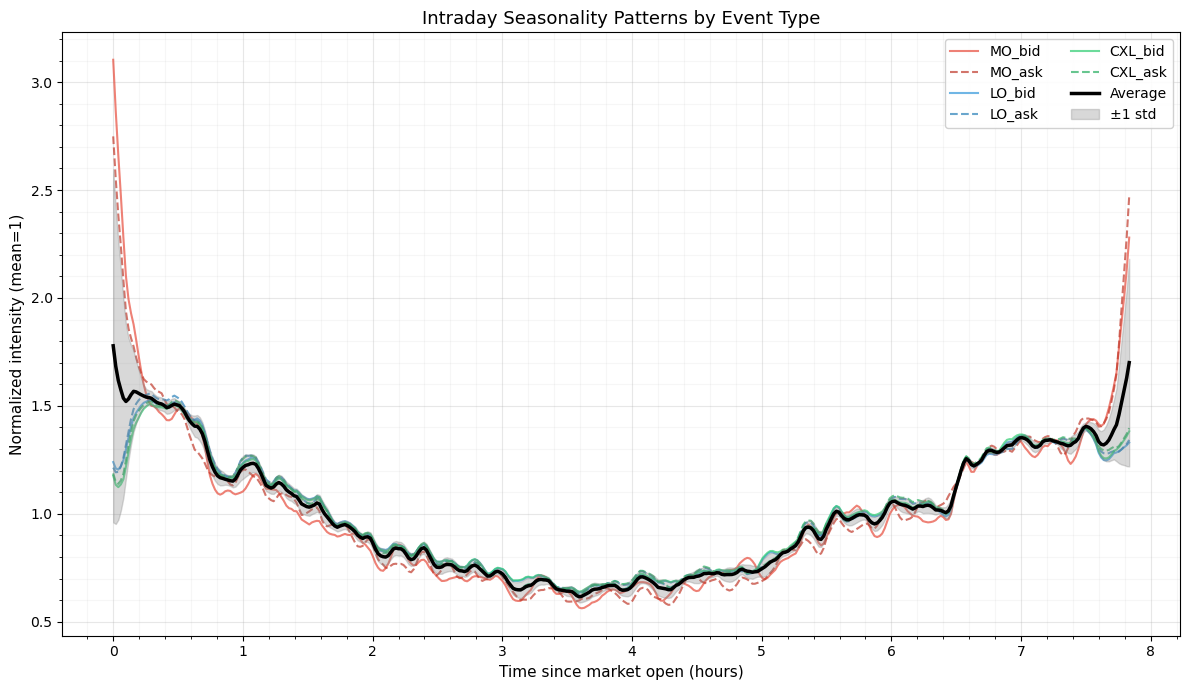

Average seasonality grid points: 400
Total tau at end of day: 28147.7371


In [ ]:
fig, ax, seasonal_stats = plot_all_seasonality_patterns(
    seasonality_profiles,
    marks_order=marks_order,
    normalize=True,
    show_average=True,
    show_uncertainty=True,
)
plt.show()

avg_seasonality = get_average_seasonality_shape(
    seasonality_profiles,
    marks_order=marks_order,
    normalize=True,
)
print(f"Average seasonality grid points: {len(avg_seasonality['grid'])}")
print(f"Total tau at end of day: {avg_seasonality['cumulative_integral'][-1]:.4f}")

## Instantiate HawkesCalibration

All subsequent calibrations are run through a single `HawkesCalibration` instance.
By passing `seasonality_profiles`, the class automatically builds the shared average
$\tau$-time transformation internally. Methods accept `use_tau=True/False`.

In [ ]:
cal = HawkesCalibration(
    timestamps_by_day=timestamps_by_day,
    marks_order=marks_order,
    end_times=end_times,
    seasonality_profiles=seasonality_profiles,
    max_iter=MAX_ITER,
    tol=TOL
)

print("HawkesCalibration ready:")
print(f"  Dimensions:   {cal.n_nodes}")
print(f"  Days:         {cal.n_days}")
print(f"  Marks:        {cal.marks_order}")
print(f"  Seasonality:  {'yes' if cal.seasonality_profiles else 'no'}")
print(f"  Fixed betas:  fast={cal.BETA_FAST}, slow={cal.BETA_SLOW}")

HawkesCalibration ready:
  Dimensions:   6
  Days:         223
  Marks:        ['MO_bid', 'MO_ask', 'LO_bid', 'LO_ask', 'CXL_bid', 'CXL_ask']
  Seasonality:  yes
  Fixed betas:  fast=15.0, slow=0.3


## 1. Poisson baseline

Constant-rate MLE: $\hat\mu_i = N_i / T_{\text{total}}$.

Fitted in both raw clock time and seasonality-adjusted $\tau$-time.

In [ ]:
poisson_raw = cal.fit_poisson(
    use_tau=False,
    day_keys=day_keys,
    gof_dims=GOF_DIMS,
)

In [ ]:
poisson_tau = cal.fit_poisson(
    use_tau=True,
    day_keys=day_keys,
    gof_dims=GOF_DIMS,
)

## 2. Univariate Hawkes -- single exponential

Each dimension is fitted independently with a single-exponential kernel:
$\phi_{ii}(t) = \alpha_{ii}\beta_{ii}e^{-\beta_{ii}t}$, with $\beta_{ii}$ searched via Optuna.

In [ ]:
uni_single_raw = cal.fit_univariate_hawkes(
    use_tau=False,
    n_trials=100,
    beta_min=0.01,
    beta_max=20.0,
    gof_dims=GOF_DIMS,
)

In [ ]:
uni_single_tau = cal.fit_univariate_hawkes(
    use_tau=True,
    n_trials=100,
    beta_min=0.01,
    beta_max=20.0,
    gof_dims=GOF_DIMS,
)

## 3. Multivariate Hawkes -- single exponential

Full 6x6 mutually-exciting Hawkes with per-kernel decay $\beta_{ij}$ searched
via parallel Optuna (subprocess workers).

In [ ]:
multi_single_raw = cal.fit_multivariate_hawkes(
    use_tau=False,
    n_trials=1000,
    n_workers=12,
    beta_min=0.1,
    beta_max=20.0,
    gof_dims=GOF_DIMS,
)

n_nodes = cal.n_nodes

plt.figure(figsize=(6, 5))
plt.imshow(multi_single_raw["adjacency"], cmap="viridis")
plt.colorbar(label="alpha")
plt.xticks(range(n_nodes), marks_order, rotation=45)
plt.yticks(range(n_nodes), marks_order)
plt.title(r"Adjacency matrix $\alpha$ (raw time)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(multi_single_raw["decays"], cmap="viridis")
plt.colorbar(label="beta")
plt.xticks(range(n_nodes), marks_order, rotation=45)
plt.yticks(range(n_nodes), marks_order)
plt.title(r"Decay matrix $\beta$ (raw time)")
plt.tight_layout()
plt.show()

In [ ]:
multi_single_tau = cal.fit_multivariate_hawkes(
    use_tau=True,
    n_trials=1000,
    n_workers=12,
    beta_min=0.1,
    beta_max=20.0,
    gof_dims=GOF_DIMS,
)

plt.figure(figsize=(6, 5))
plt.imshow(multi_single_tau["adjacency"], cmap="viridis")
plt.colorbar(label="alpha")
plt.xticks(range(n_nodes), marks_order, rotation=45)
plt.yticks(range(n_nodes), marks_order)
plt.title(r"Adjacency matrix $\alpha$ ($\tau$-time)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(multi_single_tau["decays"], cmap="viridis")
plt.colorbar(label="beta")
plt.xticks(range(n_nodes), marks_order, rotation=45)
plt.yticks(range(n_nodes), marks_order)
plt.title(r"Decay matrix $\beta$ ($\tau$-time)")
plt.tight_layout()
plt.show()

## 4. Double-exponential kernels (sum of two exponentials)

Each kernel is now a **sum of two exponentials** with **fixed** decay rates:

$$\phi_{ij}(t) = \alpha^{\text{fast}}_{ij}\,\beta_{\text{fast}}\,e^{-\beta_{\text{fast}}\,t}
              + \alpha^{\text{slow}}_{ij}\,\beta_{\text{slow}}\,e^{-\beta_{\text{slow}}\,t}$$

$\alpha$ matrices and the baseline intensities $\mu$ are calibrated; no Optuna
search over $\beta$ is needed.

In [ ]:
uni_double_raw = cal.fit_univariate_hawkes_double(
    use_tau=False,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

In [ ]:
uni_double_tau = cal.fit_univariate_hawkes_double(
    use_tau=True,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

In [ ]:
multi_double_raw = cal.fit_multivariate_hawkes_double(
    use_tau=False,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

In [ ]:
multi_double_tau = cal.fit_multivariate_hawkes_double(
    use_tau=True,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

## 5. Sum-of-exponentials with Optuna beta search (3 timescales)

Same sum-of-two-exponentials model, but now the shared decay rates
$\beta_{\text{fast}}$ and $\beta_{\text{slow}}$ are **optimized via Optuna**
For each trial, `HawkesSumExpKern` fits all alpha matrices and baselines
at the candidate betas. Search ranges: fast (10-100), mid (1-10), slow (0.01-1).

In [ ]:


uni_sumexp_optuna_raw = cal.fit_univariate_hawkes_sumexp_optuna(
    use_tau=False,
    n_trials=200,
    n_workers=12,
    beta_ranges=BETA_RANGES,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

In [ ]:
uni_sumexp_optuna_tau = cal.fit_univariate_hawkes_sumexp_optuna(
    use_tau=True,
    n_trials=200,
    n_workers=12,
    beta_ranges=BETA_RANGES,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
)

In [ ]:
multi_sumexp_optuna_raw = cal.fit_multivariate_hawkes_sumexp_optuna(
    use_tau=False,
    n_trials=300,
    n_workers=12,
    beta_ranges=BETA_RANGES,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
    slow_self_floor=SLOW_SELF_FLOOR,
)


3-exp Optuna multivariate (τ-time): 500 trials, 12 worker(s)



[I 2026-03-29 09:55:48,018] A new study created in RDB with name: sumexp_multi_τ-time_1774770947


Launched 12 workers (42 trials each, sumexp)
[W9] Worker 9 starting (42 trials, sumexp)
[W4] Worker 4 starting (42 trials, sumexp)
[W3] Worker 3 starting (42 trials, sumexp)
[W11] Worker 11 starting (42 trials, sumexp)
[W2] Worker 2 starting (42 trials, sumexp)
[W6] Worker 6 starting (42 trials, sumexp)
[W0] Worker 0 starting (42 trials, sumexp)
[W5] Worker 5 starting (42 trials, sumexp)
[W1] Worker 1 starting (42 trials, sumexp)
[W8] Worker 8 starting (42 trials, sumexp)
[W7] Worker 7 starting (42 trials, sumexp)
[W10] Worker 10 starting (42 trials, sumexp)
[W6] Trial 0 → 50.395011  (ρ=1.0393, β_0=52.5381, β_1=2.3513, β_2=0.0040)
[W11] Trial 6 → 66.937895  (ρ=1.0375, β_0=78.2629, β_1=2.0222, β_2=0.0022)
[W3] Trial 5 → 66.904518  (ρ=1.0400, β_0=78.3111, β_1=1.4736, β_2=0.0041)
[W6] [I 2026-03-29 09:56:35,197] Trial 0 finished with value: 50.395010821864574 and parameters: {'beta_0': 52.538115815729874, 'beta_1': 2.3512805816497075, 'beta_2': 0.004015301815631256}. Best is trial 0 with 

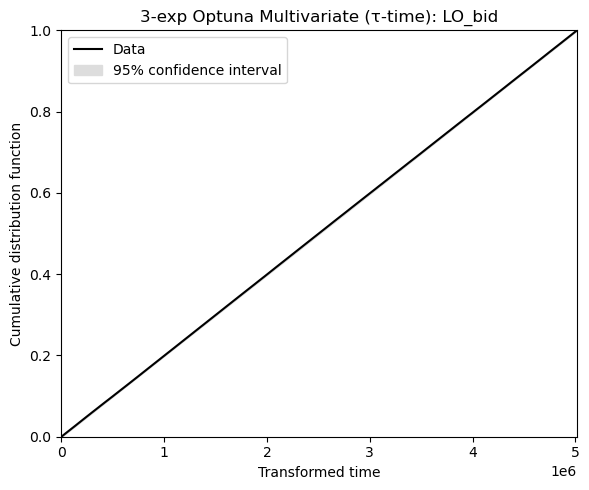

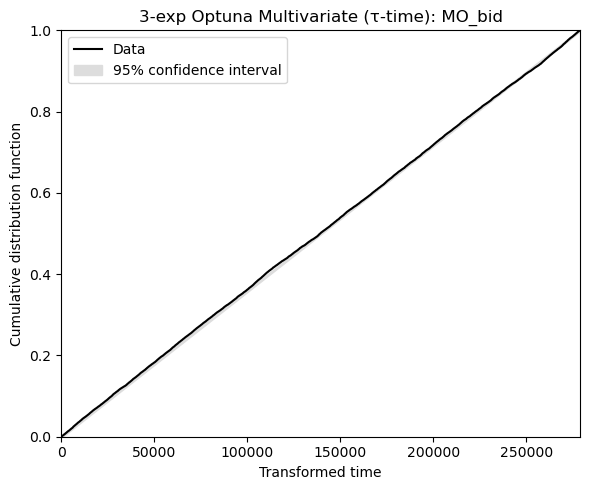

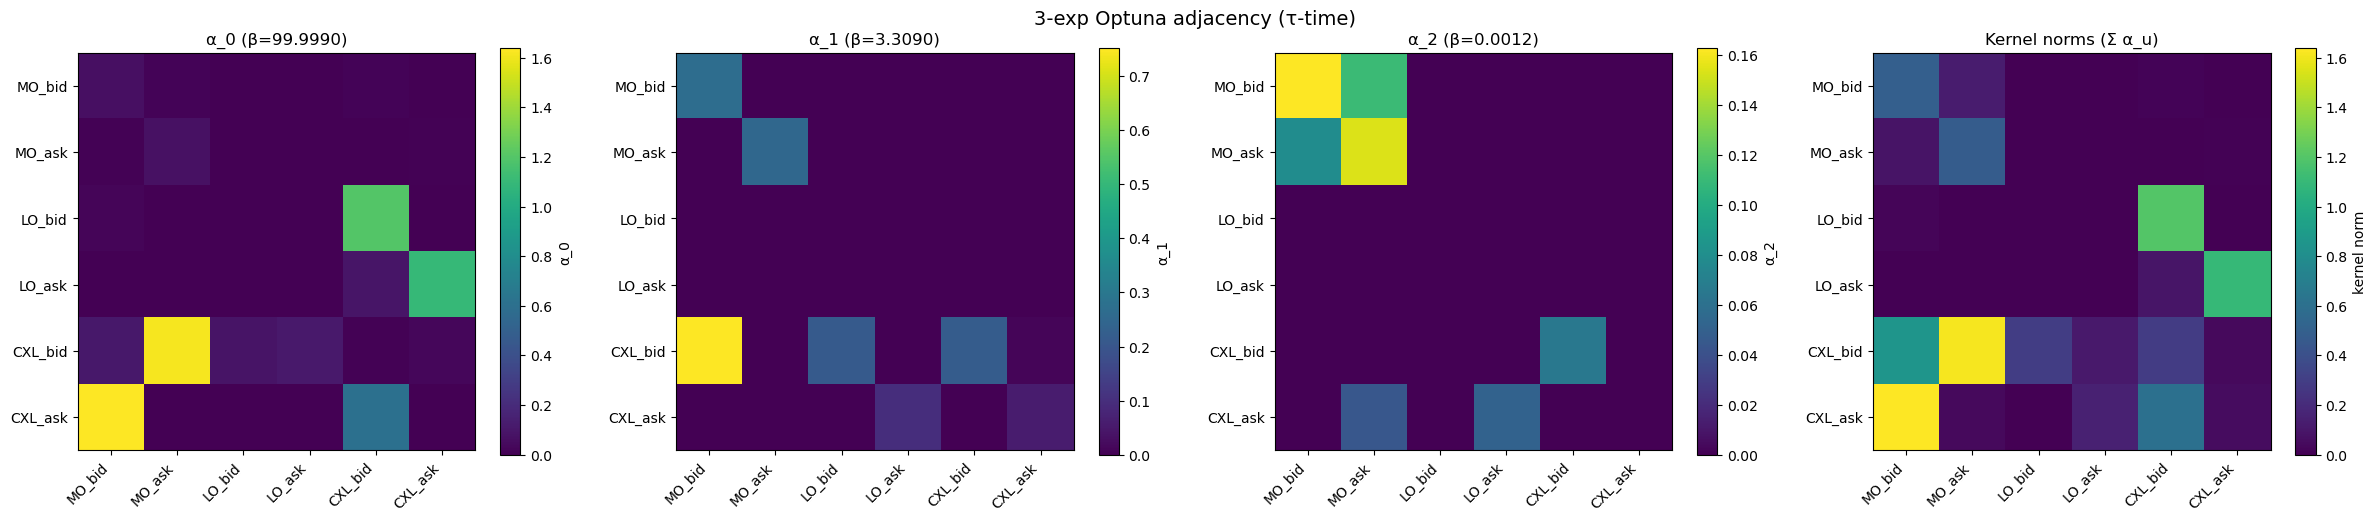

In [ ]:
multi_sumexp_optuna_tau = cal.fit_multivariate_hawkes_sumexp_optuna(
    use_tau=True,
    n_trials=500,
    n_workers=12,
    beta_ranges=BETA_RANGES,
    gof_dims=GOF_DIMS,
    penalty="l2",
    C=1e3,
    slow_self_floor=SLOW_SELF_FLOOR,
)

## Save calibrated parameters

All fitted parameter sets are saved to pickle files for downstream use
(simulation, analysis, etc.).

In [ ]:
HawkesCalibration.save_params(
    f"multivariate_hawkes_params_{asset}.pkl",
    marks=marks_order,
    baseline=multi_single_tau["baseline"],
    adjacency=multi_single_tau["adjacency"],
    decays=multi_single_tau["decays"],
)

HawkesCalibration.save_params(
    f"multivariate_hawkes_double_params_{asset}.pkl",
    marks=marks_order,
    baseline=multi_double_tau["baseline"],
    adjacency=multi_double_tau["adjacency"],
    decays=list(multi_double_tau["decays"]),
    kernel_norms=multi_double_tau["kernel_norms"],
    branching_ratio=multi_double_tau["branching_ratio"],
)

all_results = {
    "asset": asset,
    "marks_order": marks_order,
    "n_days": len(day_keys),
    "day_keys": day_keys,
    "poisson_raw": poisson_raw,
    "poisson_tau": poisson_tau,
    "uni_single_raw": {k: v for k, v in uni_single_raw.items() if k != "models"},
    "uni_single_tau": {k: v for k, v in uni_single_tau.items() if k != "models"},
    "multi_single_raw": {k: v for k, v in multi_single_raw.items() if k != "model"},
    "multi_single_tau": {k: v for k, v in multi_single_tau.items() if k != "model"},
    "uni_double_raw": {k: v for k, v in uni_double_raw.items() if k != "models"},
    "uni_double_tau": {k: v for k, v in uni_double_tau.items() if k != "models"},
    "multi_double_raw": {k: v for k, v in multi_double_raw.items() if k != "model"},
    "multi_double_tau": {k: v for k, v in multi_double_tau.items() if k != "model"},
    "uni_sumexp_optuna_raw": {k: v for k, v in uni_sumexp_optuna_raw.items() if k != "models"},
    "uni_sumexp_optuna_tau": {k: v for k, v in uni_sumexp_optuna_tau.items() if k != "models"},
    "multi_sumexp_optuna_raw": {k: v for k, v in multi_sumexp_optuna_raw.items() if k != "model"},
    "multi_sumexp_optuna_tau": {k: v for k, v in multi_sumexp_optuna_tau.items() if k != "model"},
}

HawkesCalibration.save_params(
    f"hawkes_calibration_full_{asset}.pkl",
    **all_results,
)

print("\nAll calibration results saved.")